In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from transformers import pipeline
import torch
import gc

In [2]:
df = pd.read_csv('trump_tweets_dataset.csv')
df.tail()


,id,date,platform,handle,text,favorite_count,repost_count,quote_flag,repost_flag,deleted_flag,word_count,hashtags,urls,user_mentions,media_count,media_urls,post_url,in_reply_to
90549,1773561338,2009-05-12T10:07:28-04:00,Twitter,realDonaldTrump,"""My persona will never be that of a wallflower...",1904,1345,False,False,False,21,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1773561338,NaN
90550,1741160716,2009-05-08T16:40:15-04:00,Twitter,realDonaldTrump,New Blog Post: Celebrity Apprentice Finale and...,24,11,False,False,False,13,NaN,http://www.trumpuniversity.com/blog/post/2009/...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1741160716,NaN
90551,1737479987,2009-05-08T09:38:08-04:00,Twitter,realDonaldTrump,Donald Trump reads Top Ten Financial Tips on L...,33,15,False,False,False,17,NaN,https://www.youtube.com/watch?v=hmMkZD4VcNQ&fe...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1737479987,NaN
90552,1701461182,2009-05-04T21:00:10-04:00,Twitter,realDonaldTrump,Donald Trump will be appearing on The View tom...,259,34,False,False,False,22,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1701461182,NaN
90553,1698308935,2009-05-04T14:54:25-04:00,Twitter,realDonaldTrump,Be sure to tune in and watch Donald Trump on L...,936,512,False,False,False,23,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1698308935,NaN


In [3]:
df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_convert('America/New_York')
df['year'] = df.date.dt.year

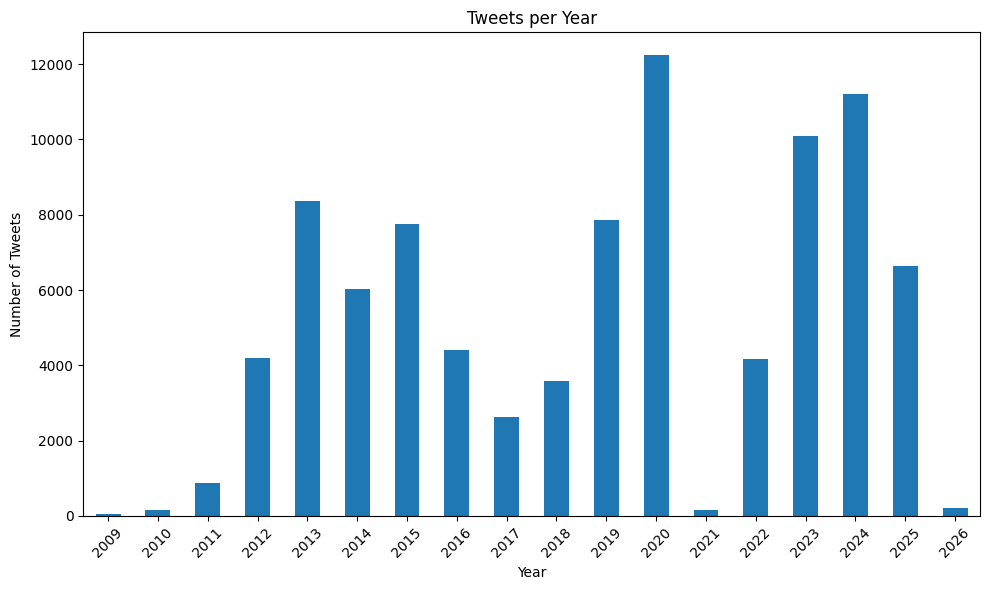

In [4]:
#tweets per year
tweets_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
tweets_per_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Tweets')
plt.title('Tweets per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
unique_tweets = df['text'].nunique()  
print(f"Unique tweets: {unique_tweets}")

print(f"Total tweets: {len(df)}")
print(f"Unique tweets: {unique_tweets}")
print(f"Duplicates: {len(df) - unique_tweets}")

Unique tweets: 82130
Total tweets: 90554
Unique tweets: 82130
Duplicates: 8424


In [8]:
df.drop_duplicates(subset = ['text'], keep='last', inplace = True)

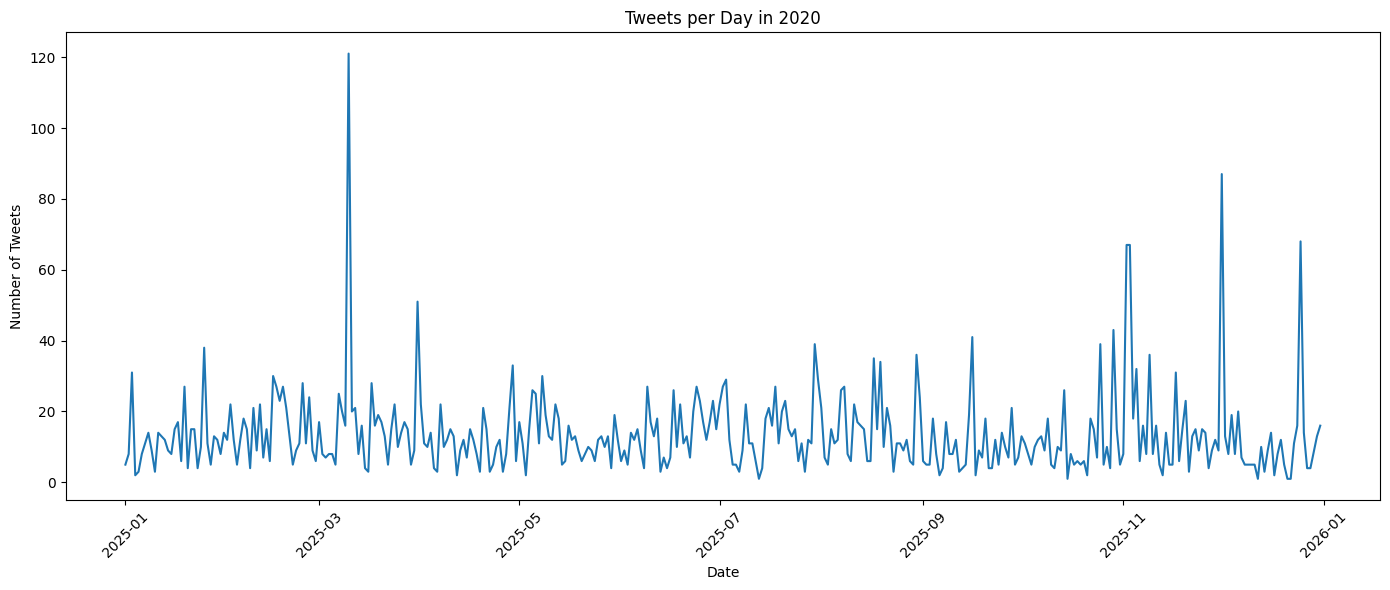

In [10]:
#tweets per day
df['day'] = df['date'].dt.date

year_to_plot = 2025
df_year = df[df['year'] == year_to_plot].copy()

tweets_per_day = df_year['day'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
tweets_per_day.plot(kind='line')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title(f'Tweets per Day in 2020')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4956 entries, 211 to 6854
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype                           
---  ------          --------------  -----                           
 0   id              4956 non-null   int64                           
 1   date            4956 non-null   datetime64[ns, America/New_York]
 2   platform        4956 non-null   object                          
 3   handle          4956 non-null   object                          
 4   text            4956 non-null   object                          
 5   favorite_count  4956 non-null   int64                           
 6   repost_count    4956 non-null   int64                           
 7   quote_flag      4956 non-null   bool                            
 8   repost_flag     4956 non-null   bool                            
 9   deleted_flag    4956 non-null   bool                            
 10  word_count      4956 non-null   int64              

In [12]:
nicknames = pd.read_csv('trump_nicknames.csv')
nicknames.head()

,nickname,person
0,Sloppy Steve,Steve Bannon
1,AOCof Tennessee,Aftyn Behn
2,Crooked Joe,Joe Biden
3,Joe Hiden,Joe Biden
4,Sleepy Joe,Joe Biden


In [13]:
nicknames

,nickname,person
0,Sloppy Steve,Steve Bannon
1,AOCof Tennessee,Aftyn Behn
2,Crooked Joe,Joe Biden
3,Joe Hiden,Joe Biden
4,Sleepy Joe,Joe Biden
...,...,...
176,Kung Flu,SARS-CoV-2
177,Chinese Virus,SARS-CoV-2
178,China virus,SARS-CoV-2
179,ObamaCare,Medicare


In [14]:
trump_nickname_map = dict(zip(
    nicknames['nickname'].str.lower().str.strip(),
    nicknames['person'].str.strip()
))

In [15]:
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

torch.cuda.empty_cache()
gc.collect()

Using device: GPU


8097

In [16]:
nlp = spacy.load("en_core_web_md")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    batch_size=8,
    max_length=128,
    truncation=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     | Details
--------------------------------+------------+--------
roberta.pooler.dense.weight     | UNEXPECTED |        
roberta.pooler.dense.bias       | UNEXPECTED |        
roberta.embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
def extract_entities_from_sentences(text):
    doc = nlp(text)
    entity_data = []
    
    for ent in doc.ents:
        entity_text = ent.text.strip()
        
        if '@' in entity_text or entity_text.startswith('RT'):
            continue
        
        
        false_positives = ['maga', 'hoax', 'witch hunt', 'djt', 'fake news',
                            'gop', 'rsbn']
        if entity_text.lower() in false_positives:
            continue
        
        trump_refs = ['trump', 'donald', 'donald trump', 'donald j. trump', 'donald j trump']
        if entity_text.lower() in trump_refs:
            continue
        
        if len(entity_text) <= 2:
            continue

        text_clean = entity_text.lower().strip()
        if text_clean in trump_nickname_map:
            normalized = trump_nickname_map[text_clean]
        else:
            normalized = entity_text
            prefixes = ['crooked', 'sleepy', 'lyin', 'lying', 'crazy', 
                       'little', 'mini', 'low energy', 'nervous', 'shifty']
            
            for prefix in prefixes:
                if text_clean.startswith(prefix + ' '):
                    name_part = text_clean.replace(prefix + ' ', '').strip()
                    if name_part in trump_nickname_map:
                        normalized = trump_nickname_map[name_part]
                        break
            
            name_expansions = {
                'obama': 'Barack Obama',
                'biden': 'Joe Biden',
                'joe': 'Joe Biden',
                'hillary': 'Hillary Clinton',
                'clinton': 'Hillary Clinton',
                'bernie': 'Bernie Sanders',
                'pelosi': 'Nancy Pelosi',
                'schumer': 'Chuck Schumer',
                'comey': 'James Comey',
                'mueller': 'Robert Mueller',
                'flynn': 'Michael Flynn',
                'pence': 'Mike Pence',
                'cruz': 'Ted Cruz',
                'rubio': 'Marco Rubio',
                'rivlin': 'Reuven Rivlin'
            }
            
            if text_clean in name_expansions:
                normalized = name_expansions[text_clean]
        
        
        sentence = ent.sent.text.strip()
        
        entity_data.append({
            'original': entity_text,
            'normalized': normalized,
            'type': ent.label_,
            'sentence': sentence
            
        })
    
    return entity_data



In [19]:
df['text'] = df['text'].fillna('').astype(str)
all_entity_sentence_pairs = []

for idx, row in df.iterrows():
    entities = extract_entities_from_sentences(row['text'])
    
    for entity in entities:
        all_entity_sentence_pairs.append({
            'tweet_id': row['id'],
            'date': row['date'],
            'entity_normalized': entity['normalized'],
            'type': entity['type'],
            'sentence': entity['sentence'],
            'full_text': row['text']
        })
    

entities_sentences_df = pd.DataFrame(all_entity_sentence_pairs)
entities_sentences_df.head()


,tweet_id,date,entity_normalized,type,sentence,full_text
0,115859532176676320,2026-01-08 07:42:42-05:00,Somali,NORP,Somali cash exodus from Minneapolis exponentia...,Arrest them all. They are criminals!!! \nForei...
1,115859532176676320,2026-01-08 07:42:42-05:00,Minneapolis,GPE,Somali cash exodus from Minneapolis exponentia...,Arrest them all. They are criminals!!! \nForei...
2,115859532176676320,2026-01-08 07:42:42-05:00,minneapolis,GPE,Somali cash exodus from Minneapolis exponentia...,Arrest them all. They are criminals!!! \nForei...
3,115857498674115807,2026-01-07 23:05:33-05:00,Nicole Parker,PERSON,When a vehicle is coming at you and is being u...,When a vehicle is coming at you and is being u...
4,115856506155736586,2026-01-07 18:53:08-05:00,Colombia,GPE,It was a Great Honor to speak with the Preside...,It was a Great Honor to speak with the Preside...


In [20]:
all_sentiments = []
batch_size = 8

sentences = entities_sentences_df['sentence'].tolist()

for i in range(0, len(sentences), batch_size):
    batch_sentences = sentences[i:i+batch_size]
    batch_sentences = [str(s)[:256] for s in batch_sentences]
    
    try:
        results = sentiment_pipeline(batch_sentences)
        
        for result in results:
            label_map = {'negative': -1, 'neutral': 0, 'positive': 1}
            direction = label_map.get(result['label'].lower(), 0)
            
            all_sentiments.append({
                'sentiment_compound': direction * result['score'],
                'sentiment_label': result['label'],
                'sentiment_confidence': result['score']
            })
    except Exception as e:
        print(f"Error at batch {i}: {e}")
        for _ in range(len(batch_sentences)):
            all_sentiments.append({
                'sentiment_compound': 0.0,
                'sentiment_label': 'neutral',
                'sentiment_confidence': 0.0
            })

        torch.cuda.empty_cache()




You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [22]:
sentiments_df = pd.DataFrame(all_sentiments)
entities_sentiment_df = pd.concat([entities_sentences_df, sentiments_df], axis=1)

In [23]:
entities_sentiment_df.to_csv('entities_sentiment_dataset.csv',index = False)

In [24]:
entities_sentiment_df.columns

Index(['tweet_id', 'date', 'entity_normalized', 'type', 'sentence',
       'full_text', 'sentiment_compound', 'sentiment_label',
       'sentiment_confidence'],
      dtype='object')

In [26]:
#vader sentiment
vader = SentimentIntensityAnalyzer()



def get_sentiment(text):
    scores = vader.polarity_scores(text)
    return scores

df['sentiment'] = df['text'].apply(get_sentiment)

df['sentiment_compound'] = df['sentiment'].apply(lambda x: x['compound'])
df['sentiment_positive'] = df['sentiment'].apply(lambda x: x['pos'])
df['sentiment_negative'] = df['sentiment'].apply(lambda x: x['neg'])
df['sentiment_neutral'] = df['sentiment'].apply(lambda x: x['neu'])

def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_compound'].apply(categorize_sentiment)



In [27]:
df.to_csv('og_dataset.csv',index= False)